In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

2025-06-20 19:09:06.624909: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750446546.808830      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750446546.868121      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
df = pd.read_csv('/kaggle/input/asldataset/SignSpeakDataset.csv')

feature_columns = df.columns.drop('word')
df[feature_columns] = df[feature_columns].fillna(0)

print("Dataset Head:")
print(df.head())

print("\nNumber of unique signs:", df['word'].nunique())

Dataset Head:
                        _id word  hand[0][0]  hand[0][1]  hand[0][2]  \
0  6601f2a1108f932c23d100d7    a        1023         126          59   
1  6601f2a5108f932c23d100d8    a         778         115          62   
2  6601f2ab108f932c23d100d9    a        1023         136          93   
3  6601f2ae108f932c23d100da    a        1023         175         111   
4  6601f2b0108f932c23d100db    a        1022         315         432   

   hand[0][3]  hand[0][4]  hand[1][0]  hand[1][1]  hand[1][2]  ...  \
0          24          90        1023         116          54  ...   
1          24          42         777          99          67  ...   
2          27          30        1023         128          86  ...   
3          44          70        1023         126          71  ...   
4         108         374        1023         229         178  ...   

   hand[77][0]  hand[77][1]  hand[77][2]  hand[77][3]  hand[77][4]  \
0          0.0          0.0          0.0          0.0         

In [3]:
feature_columns = df.columns[1:] 
X = df[feature_columns].values
y = df['word'].values

In [4]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

num_classes = len(label_encoder.classes_)
y_categorical = tf.keras.utils.to_categorical(y_encoded, num_classes=num_classes)

In [5]:
from sklearn.preprocessing import StandardScaler

X_numeric = pd.DataFrame(X).apply(pd.to_numeric, errors='coerce')

X_numeric = X_numeric.fillna(0).values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_numeric)

X_reshaped = np.reshape(X_scaled, (X_scaled.shape[0], 1, X_scaled.shape[1]))

print("Reshaped feature shape:", X_reshaped.shape)

Reshaped feature shape: (7200, 1, 396)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X_reshaped, 
    y_categorical, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_encoded
)

In [7]:
model = tf.keras.Sequential([
    tf.keras.layers.LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.LSTM(128, return_sequences=False),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

model.summary()

I0000 00:00:1750446561.536708      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1750446561.537518      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 1, 64)               │         118,016 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1, 64)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 128)                 │          98,816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 36)                  │           2,340 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 243,940 (952.89 KB)

 Trainable params: 243,940 (952.89 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.compile(optimizer='adam', 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])

In [9]:
history = model.fit(
    X_train, 
    y_train, 
    epochs=50, 
    batch_size=32, 
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/50


I0000 00:00:1750446566.922138      61 cuda_dnn.cc:529] Loaded cuDNN version 90300


180/180 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.2131 - loss: 2.8380 - val_accuracy: 0.5312 - val_loss: 1.1700
Epoch 2/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5706 - loss: 1.1215 - val_accuracy: 0.6583 - val_loss: 0.8549
Epoch 3/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6508 - loss: 0.8744 - val_accuracy: 0.7167 - val_loss: 0.7355
Epoch 4/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7216 - loss: 0.7438 - val_accuracy: 0.7917 - val_loss: 0.6136
Epoch 5/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7716 - loss: 0.6223 - val_accuracy: 0.7674 - val_loss: 0.5955
Epoch 6/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7923 - loss: 0.5736 - val_accuracy: 0.8146 - val_loss: 0.5505
Epoch 7/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8141 - loss: 0.5145 - val_accuracy: 0.8146 - val_loss: 0.5600
Epoch 8/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8181 - loss: 0.4943 - val_accuracy: 0.8486 - val_

In [10]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy*100:.2f}%")


Test Loss: 0.3988
Test Accuracy: 90.42%


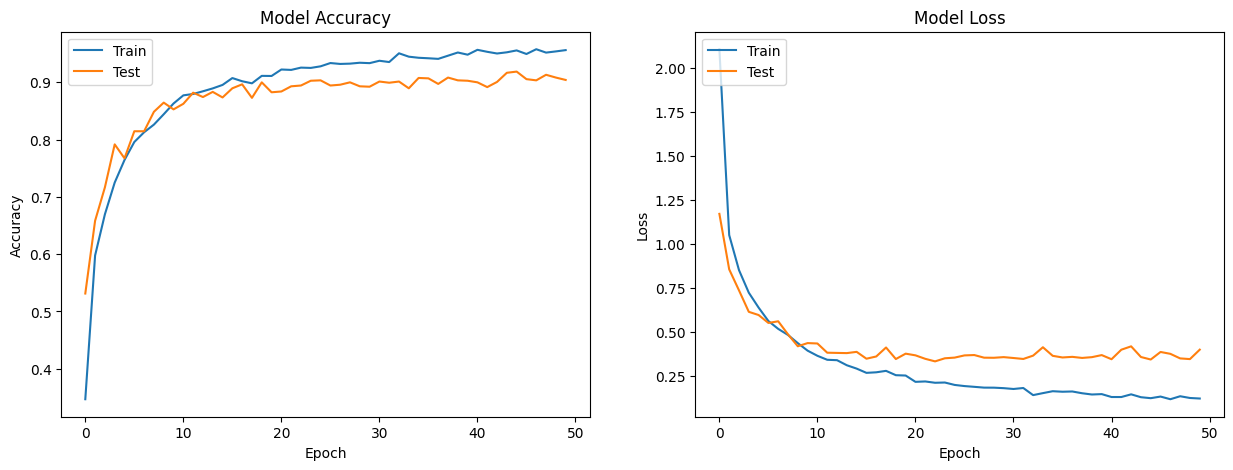

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(history.history['accuracy'])
ax1.plot(history.history['val_accuracy'])
ax1.set_title('Model Accuracy')
ax1.set_ylabel('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend(['Train', 'Test'], loc='upper left')

ax2.plot(history.history['loss'])
ax2.plot(history.history['val_loss'])
ax2.set_title('Model Loss')
ax2.set_ylabel('Loss')
ax2.set_xlabel('Epoch')
ax2.legend(['Train', 'Test'], loc='upper left')

plt.show()

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Classification Report:

              precision    recall  f1-score   support

           1       0.90      0.95      0.93        40
          10       1.00      1.00      1.00        40
           2       0.93      0.95      0.94        40
           3       0.97      0.88      0.92        40
           4       0.98      1.00      0.99        40
           5       0.97      0.97      0.97        40
           6       1.00      1.00      1.00        40
           7       0.98      1.00      0.99        40
           8       1.00      1.00      1.00        40
           9       0.98      1.00      0.99        40
           a       0.79      0.95      0.86        40
           b       0.97      0.97      0.97        40
           c       0.88      0.90      0.89        40
           d       0.80      0.82      0.81        40
           e       0.97      0.93      0.95        40
           f       0.98      1.00      0.99        40
           g     

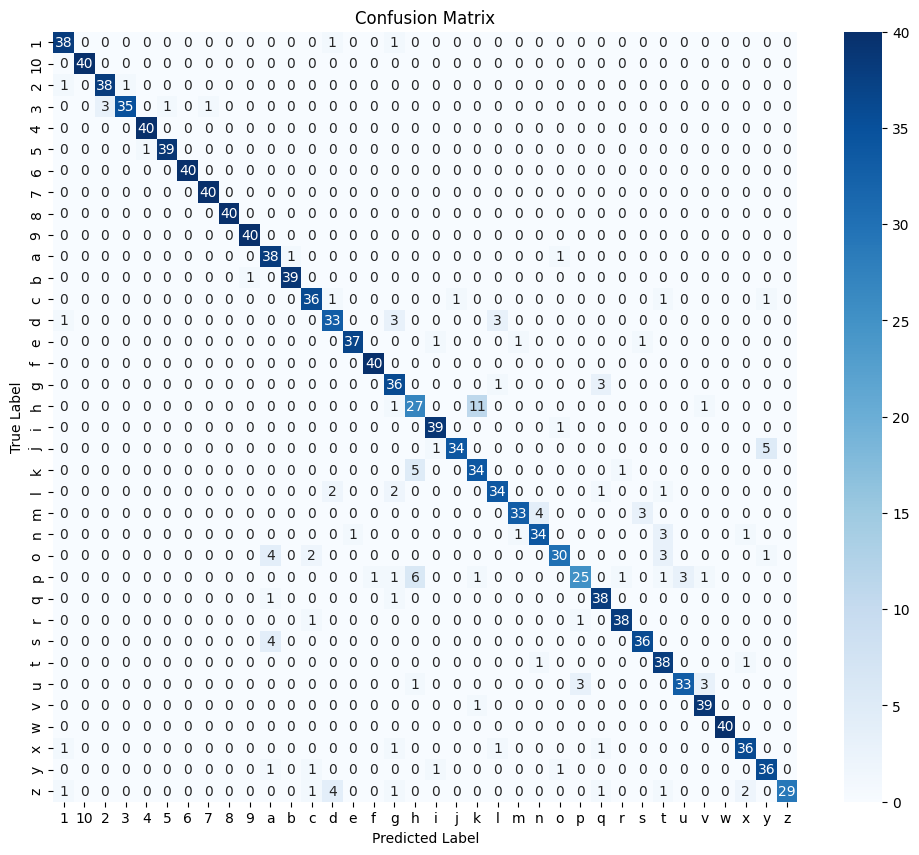

In [12]:
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

class_names = label_encoder.classes_

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

plt.figure(figsize=(12, 10))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()